In [1]:
# install libraries (run once)
# pip install seaborn pandas

import seaborn as sns
import pandas as pd

# Load dataset from seaborn
df = sns.load_dataset("tips")

# Save to csv (optional)
df.to_csv("tips.csv", index=False)

# Show first 5 rows
print(df.head())

# Check dataset info
print("\nDataset Info:")
print(df.info())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None


In [2]:
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2



================ KPI RESULTS ================

Total Revenue: 4827.77
Total Tips Collected: 731.58
Average Tip %: 16.08
Average Bill per Customer: 19.79


Peak Revenue Day: Sat

Revenue by Time:
time
Lunch     1167.47
Dinner    3660.30
Name: total_bill, dtype: float64

Smoking vs Non-Smoking Revenue:
smoker
Yes    1930.34
No     2897.43
Name: total_bill, dtype: float64

Full Summary:
       total_bill         tip        size  tip_percent
count  244.000000  244.000000  244.000000   244.000000
mean    19.785943    2.998279    2.569672    16.080258
std      8.902412    1.383638    0.951100     6.107220
min      3.070000    1.000000    1.000000     3.563814
25%     13.347500    2.000000    2.000000    12.912736
50%     17.795000    2.900000    2.000000    15.476977
75%     24.127500    3.562500    3.000000    19.147549
max     50.810000   10.000000    6.000000    71.034483


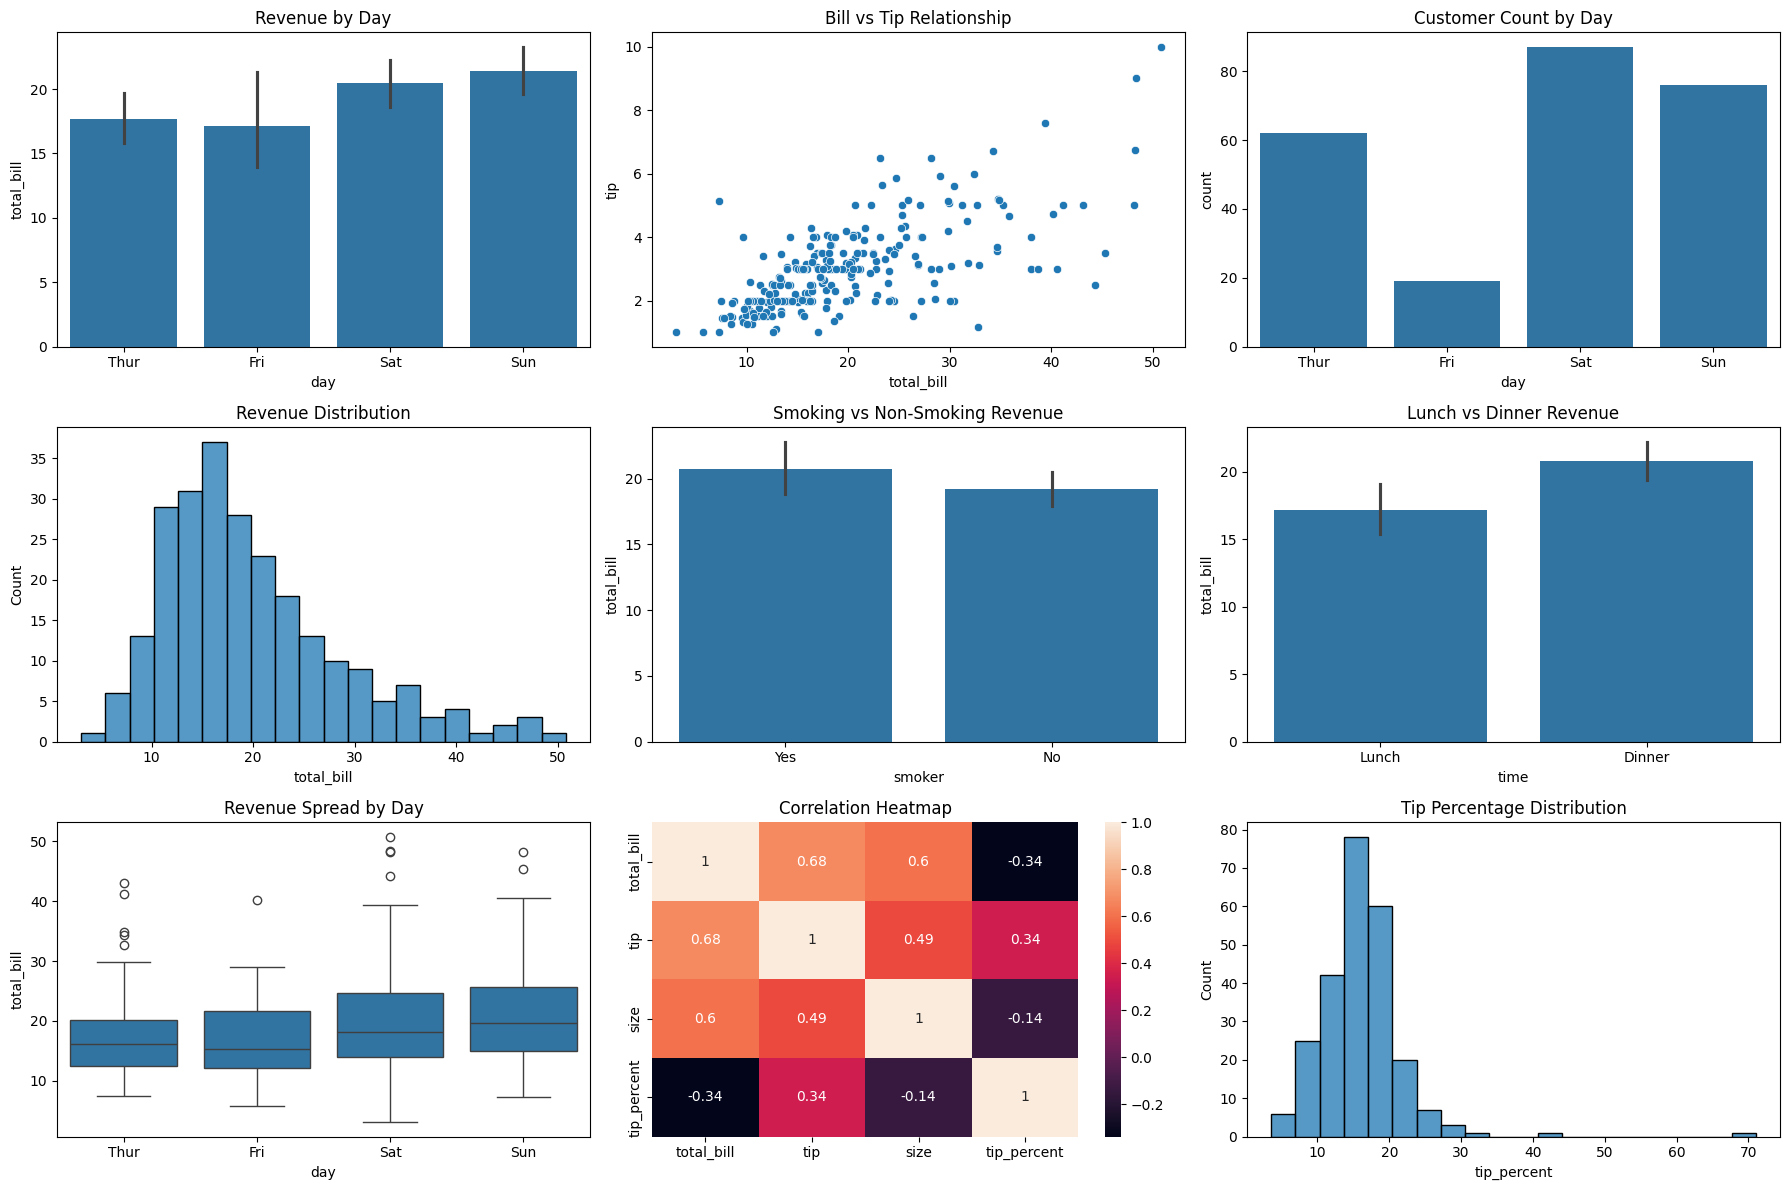

In [3]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = sns.load_dataset("tips")

print("\n================ KPI RESULTS ================\n")

# KPI 1: Total Revenue
total_revenue = df['total_bill'].sum()
print("Total Revenue:", round(total_revenue,2))


# KPI 2: Total Tips
total_tips = df['tip'].sum()
print("Total Tips Collected:", round(total_tips,2))


# KPI 3: Average Tip %
df['tip_percent'] = (df['tip'] / df['total_bill']) * 100
avg_tip_percent = df['tip_percent'].mean()
print("Average Tip %:", round(avg_tip_percent,2))


# KPI 4: Average Bill per Customer
avg_bill = df['total_bill'].mean()
print("Average Bill per Customer:", round(avg_bill,2))


# KPI 5: Peak Revenue Day
peak_day = df.groupby('day', observed=True)['total_bill'].sum().idxmax()
print("Peak Revenue Day:", peak_day)


# KPI 6: Revenue by Time
time_revenue = df.groupby('time', observed=True)['total_bill'].sum()
print("\nRevenue by Time:")
print(time_revenue)


# KPI 7: Smoking vs Non Smoking Revenue
smoke_revenue = df.groupby('smoker', observed=True)['total_bill'].sum()
print("\nSmoking vs Non-Smoking Revenue:")
print(smoke_revenue)


print("\nFull Summary:")
print(df.describe())


# ====================================
# ALL IMPORTANT CHARTS
# ====================================

plt.figure(figsize=(18,12))


# Chart 1: Revenue by Day (Bar Chart)
plt.subplot(3,3,1)
sns.barplot(x="day", y="total_bill", data=df)
plt.title("Revenue by Day")


# Chart 2: Bill vs Tip (Scatter)
plt.subplot(3,3,2)
sns.scatterplot(x="total_bill", y="tip", data=df)
plt.title("Bill vs Tip Relationship")


# Chart 3: Customer Count by Day
plt.subplot(3,3,3)
sns.countplot(x="day", data=df)
plt.title("Customer Count by Day")


# Chart 4: Revenue Distribution
plt.subplot(3,3,4)
sns.histplot(df["total_bill"], bins=20)
plt.title("Revenue Distribution")


# Chart 5: Smoking vs Non Smoking Revenue
plt.subplot(3,3,5)
sns.barplot(x="smoker", y="total_bill", data=df)
plt.title("Smoking vs Non-Smoking Revenue")


# Chart 6: Lunch vs Dinner Revenue
plt.subplot(3,3,6)
sns.barplot(x="time", y="total_bill", data=df)
plt.title("Lunch vs Dinner Revenue")


# Chart 7: Boxplot Revenue Distribution
plt.subplot(3,3,7)
sns.boxplot(x="day", y="total_bill", data=df)
plt.title("Revenue Spread by Day")


# Chart 8: Heatmap Correlation
plt.subplot(3,3,8)
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")


# Chart 9: Tip Percentage Distribution
plt.subplot(3,3,9)
sns.histplot(df["tip_percent"], bins=20)
plt.title("Tip Percentage Distribution")


plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Revenue by Day')

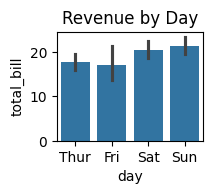

In [4]:
plt.subplot(3,3,1)
sns.barplot(x="day", y="total_bill", data=df)
plt.title("Revenue by Day")

In [5]:
df.head()

,total_bill,tip,sex,smoker,day,time,size,tip_percent
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765


In [6]:
df.tail()

,total_bill,tip,sex,smoker,day,time,size,tip_percent
239,29.03,5.92,Male,No,Sat,Dinner,3,20.392697
240,27.18,2.00,Female,Yes,Sat,Dinner,2,7.358352
241,22.67,2.00,Male,Yes,Sat,Dinner,2,8.822232
242,17.82,1.75,Male,No,Sat,Dinner,2,9.820426
243,18.78,3.00,Female,No,Thur,Dinner,2,15.974441


In [7]:
Total_Revenue=df['total_bill'].sum()
Total_Revenue

np.float64(4827.77)

In [8]:
df.size

1952

In [9]:
df.describe

<bound method NDFrame.describe of      total_bill   tip     sex smoker   day    time  size  tip_percent
0         16.99  1.01  Female     No   Sun  Dinner     2     5.944673
1         10.34  1.66    Male     No   Sun  Dinner     3    16.054159
2         21.01  3.50    Male     No   Sun  Dinner     3    16.658734
3         23.68  3.31    Male     No   Sun  Dinner     2    13.978041
4         24.59  3.61  Female     No   Sun  Dinner     4    14.680765
..          ...   ...     ...    ...   ...     ...   ...          ...
239       29.03  5.92    Male     No   Sat  Dinner     3    20.392697
240       27.18  2.00  Female    Yes   Sat  Dinner     2     7.358352
241       22.67  2.00    Male    Yes   Sat  Dinner     2     8.822232
242       17.82  1.75    Male     No   Sat  Dinner     2     9.820426
243       18.78  3.00  Female     No  Thur  Dinner     2    15.974441

[244 rows x 8 columns]>

In [10]:
df

,total_bill,tip,sex,smoker,day,time,size,tip_percent
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,20.392697
240,27.18,2.00,Female,Yes,Sat,Dinner,2,7.358352
241,22.67,2.00,Male,Yes,Sat,Dinner,2,8.822232
242,17.82,1.75,Male,No,Sat,Dinner,2,9.820426


In [11]:
df.info

<bound method DataFrame.info of      total_bill   tip     sex smoker   day    time  size  tip_percent
0         16.99  1.01  Female     No   Sun  Dinner     2     5.944673
1         10.34  1.66    Male     No   Sun  Dinner     3    16.054159
2         21.01  3.50    Male     No   Sun  Dinner     3    16.658734
3         23.68  3.31    Male     No   Sun  Dinner     2    13.978041
4         24.59  3.61  Female     No   Sun  Dinner     4    14.680765
..          ...   ...     ...    ...   ...     ...   ...          ...
239       29.03  5.92    Male     No   Sat  Dinner     3    20.392697
240       27.18  2.00  Female    Yes   Sat  Dinner     2     7.358352
241       22.67  2.00    Male    Yes   Sat  Dinner     2     8.822232
242       17.82  1.75    Male     No   Sat  Dinner     2     9.820426
243       18.78  3.00  Female     No  Thur  Dinner     2    15.974441

[244 rows x 8 columns]>

<Axes: >

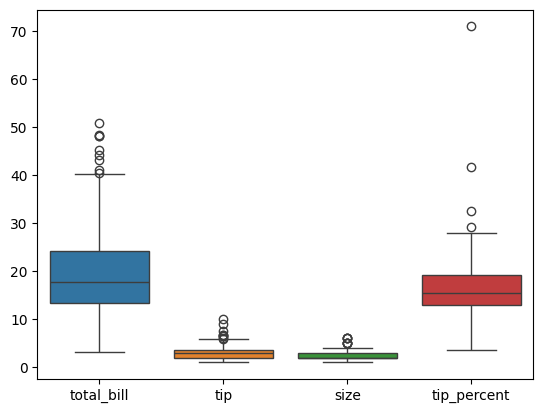

In [12]:
sns.boxplot(df)

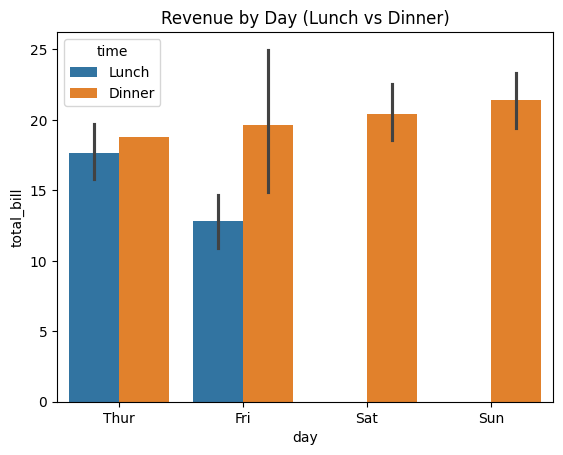

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("tips")

sns.barplot(x="day", y="total_bill", hue="time", data=df)

plt.title("Revenue by Day (Lunch vs Dinner)")
plt.show()

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt 
from dash import html,dcc,Input,Output

In [ ]:
import dash
from dash import dcc, html
import plotly.express as px
import seaborn as sns
import pandas as pd

# Load dataset
df = sns.load_dataset("tips")

# KPI values
total_revenue = round(df['total_bill'].sum(),2)
total_tips = round(df['tip'].sum(),2)
avg_tip_percent = round(((df['tip']/df['total_bill'])*100).mean(),2)
avg_bill = round(df['total_bill'].mean(),2)
peak_day = df.groupby('day', observed=True)['total_bill'].sum().idxmax()


# Card Style (MOVE HERE ✅)
card_style = {
    'border':'2px solid black',
    'padding':'20px',
    'margin':'10px',
    'width':'23%',
    'textAlign':'center',
    'backgroundColor':'lightblue',
    'display':'inline-block'
}


# Charts

fig1 = px.bar(df, x="day", y="total_bill", title="Revenue by Day")

fig2 = px.scatter(df, x="total_bill", y="tip", title="Bill vs Tip")

fig3 = px.histogram(df, x="day", title="Customer Count")

fig4 = px.histogram(df, x="total_bill", title="Revenue Distribution")

fig5 = px.bar(df, x="smoker", y="total_bill", title="Smoking Revenue")

fig6 = px.bar(df, x="time", y="total_bill", title="Lunch vs Dinner")

fig7 = px.box(df, x="day", y="total_bill", title="Revenue Spread")

fig8 = px.imshow(df.corr(numeric_only=True), text_auto=True, title="Heatmap")

fig9 = px.histogram((df['tip']/df['total_bill'])*100, title="Tip % Distribution")


# App
app = dash.Dash(__name__)


# Layout
app.layout = html.Div([

    html.H1("Restaurant KPI Dashboard", style={'textAlign':'center'}),

    html.Div([

        html.Div([
            html.H3("Total Revenue"),
            html.H2(total_revenue)
        ], style=card_style),

        html.Div([
            html.H3("Total Tips"),
            html.H2(total_tips)
        ], style=card_style),

        html.Div([
            html.H3("Avg Tip %"),
            html.H2(avg_tip_percent)
        ], style=card_style),

        html.Div([
            html.H3("Peak Day"),
            html.H2(peak_day)
        ], style=card_style),

    ]),

    dcc.Graph(figure=fig1),
    dcc.Graph(figure=fig2),
    dcc.Graph(figure=fig3),
    dcc.Graph(figure=fig4),
    dcc.Graph(figure=fig5),
    dcc.Graph(figure=fig6),
    dcc.Graph(figure=fig7),
    dcc.Graph(figure=fig8),
    dcc.Graph(figure=fig9),

])


# Run
if __name__ == "__main__":
    app.run(debug=True)

In [ ]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   Day_19_26_02_2026.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	Untitled10.ipynb
	tips.csv

no changes added to commit (use "git add" and/or "git commit -a")


In [ ]:
!git add .

In [ ]:
!git commit -m "27_02_2026"

[main 6519a93] 27_02_2026
 3 files changed, 1540 insertions(+), 99 deletions(-)
 create mode 100644 Untitled10.ipynb
 create mode 100644 tips.csv


In [ ]:
!git push origin main 

To https://github.com/Musa-04/Work_From_Jupyter_NoteBook.git
   0fb625d..6519a93  main -> main
